In [1]:
import hoda
import tensorly as tl

tl.set_backend('cupy', local_threadsafe=False)
print(tl.get_backend())
%pip install toeplitzlda
%pip freeze | grep moabb

cupy

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation


paradigm = P300(resample=64)
datasets = [
    #BI2012(),
    #BI2013a(),
    #BI2014a(),
    #BI2014b(),
    #BI2015a(),
    #BI2015b(),
    BNCI2014_008(),
    #BNCI2014_009(),
    #EPFLP300(),
    #BNCI2015_003(),
    #Cattan2019_VR(),
    #Huebner2017(),
    #Huebner2018(),
    #Lee2019_ERP(),
    #Sosulski2019(),
]

evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=datasets,
    overwrite=False,
    random_state=42,
    n_jobs=4
)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


In [3]:
from sklearn.pipeline import Pipeline
from hoda.hoda import HODA, BTTDA, InfoBTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from hoda.classification import Vectorize, ToeplitzLDAWrapper, SelectF, Tensor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
from sklearn.linear_model import LogisticRegression

pipelines = dict()


hoda_params = dict(
    max_iter=128,
    tol=1e-12,
    init ='random',
    random_state=42,
    shrinkage='lw',
    solver='lanczos',
    taper=False,
    forward=False,
    ortho=False,
    obj='rt',
    toeplitz=None
)

pipelines['HODA'] = Pipeline([
    ('gpu', Tensor()),
    ('clf', GridSearchCV(
        Pipeline([
            ('hoda', HODA(**hoda_params,    delta=None,)),
            ('vec', Vectorize()),
            ('zscore', StandardScaler()),
            ('lda', LDA(shrinkage='auto', solver='lsqr')),
        ]),
        param_grid=dict(hoda__rank=[1,2,4,8]),
        n_jobs=4
    )),
])

pipelines['tLDA'] = ToeplitzLDAWrapper()


pipelines['BTTDA_bic_16_truncate'] = Pipeline([
    ('bttda', InfoBTTDA(ranks=[None]*16,hoda_params=hoda_params,info_crit='bic', truncate=True)),
    ('vec', Vectorize()),
    ('zscore', StandardScaler()),
    ('lda', LDA(shrinkage='auto', solver='lsqr')),
])


In [4]:
#import warnings
#warnings.filterwarnings("ignore")

results = evaluation.process(pipelines)

BNCI2014-008-WithinSession:   0%|                                                               | 0/8 [00:00<?, ?it/s]

No hdf5_path provided, models will not be saved.


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.chann

No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  25%|█████████████▊                                         | 2/8 [03:01<09:09, 91.62s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


...

BNCI2014-008-WithinSession:  75%|█████████████████████████████████████████▎             | 6/8 [09:09<03:04, 92.44s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  88%|████████████████████████████████████████████████▏      | 7/8 [10:47<01:34, 94.25s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession: 100%|███████████████████████████████████████████████████████| 8/8 [12:13<00:00, 91.67s/it]


In [5]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.827786,0.662134,4200.0,1,0,8,1,BNCI2014-008,tLDA
1,0.805020,0.125318,4200.0,2,0,8,1,BNCI2014-008,tLDA
2,0.882718,0.106916,4200.0,3,0,8,1,BNCI2014-008,tLDA
3,0.802761,0.107522,4200.0,4,0,8,1,BNCI2014-008,tLDA
4,0.852180,0.108972,4200.0,5,0,8,1,BNCI2014-008,tLDA
5,0.890404,0.110518,4200.0,6,0,8,1,BNCI2014-008,tLDA
6,0.872888,0.105570,4200.0,7,0,8,1,BNCI2014-008,tLDA
7,0.951237,0.113529,4200.0,8,0,8,1,BNCI2014-008,tLDA
8,0.823369,33.721584,4200.0,1,0,8,1,BNCI2014-008,BTTDA_bic_16_truncate
9,0.804316,38.351318,4200.0,2,0,8,1,BNCI2014-008,BTTDA_bic_16_truncate


In [6]:
results.groupby(['dataset','session', 'pipeline']).aggregate('mean') 

/tmp/ipykernel_3080/3374554284.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  results.groupby(['dataset','session', 'pipeline']).aggregate('mean')


score       time  \
dataset      session pipeline                                                
BNCI2014-008 0       BTTDA_bic_16_truncate             0.856652  36.082165   
                     BTTDA_bic_8_truncate_select-0.95  0.854654  17.454977   
                     HODA                              0.854353   8.255627   
                     tLDA                              0.860624   0.180060   

                                                       samples  channels  \
dataset      session pipeline                                              
BNCI2014-008 0       BTTDA_bic_16_truncate              4200.0       8.0   
                     BTTDA_bic_8_truncate_select-0.95   4200.0       8.0   
                     HODA                               4200.0       8.0   
                     tLDA                               4200.0       8.0   

                                                       n_sessions  
dataset      session pipeline                                      
BNCI2014-008 0       BTTDA_bic_16_truncate                    1.0  
                     BTTDA_bic_8_truncate_select-0.95         1.0  
                     HODA                                     1.0  
                     tLDA                                     1.0

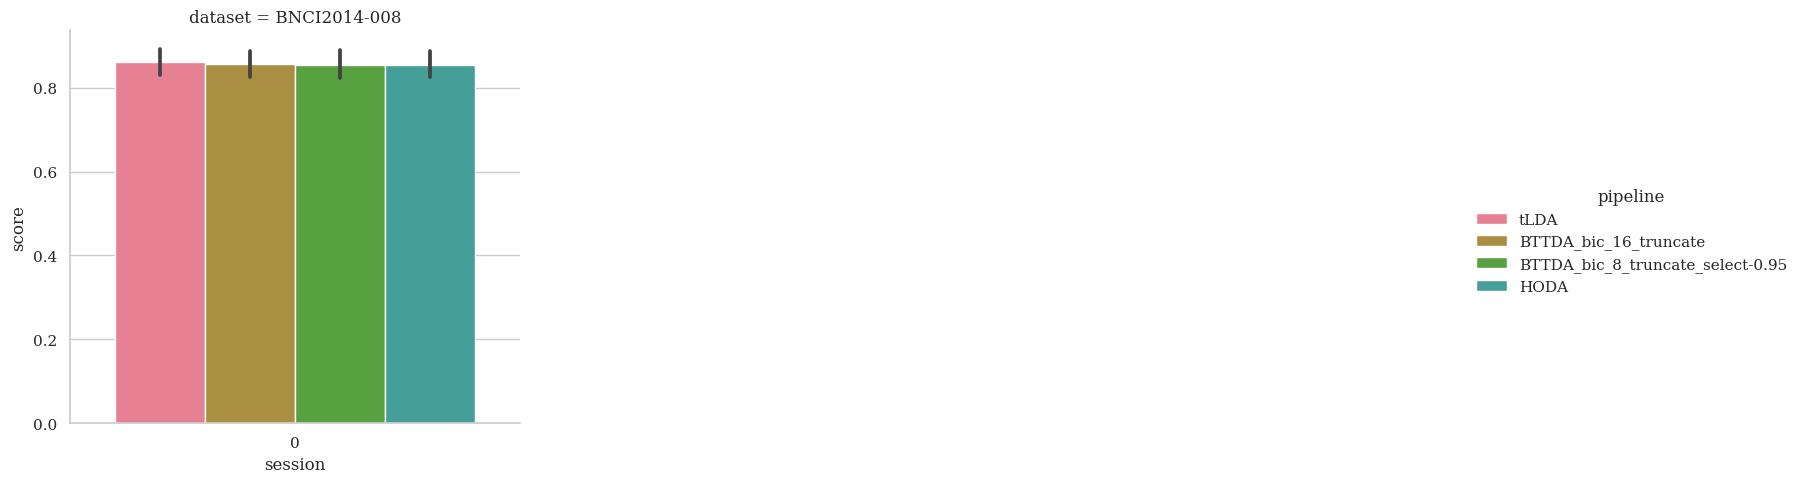

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()


sns.catplot(data=results, x='session', y='score', col='dataset',hue='pipeline', col_wrap=3,kind='bar')
plt.show()

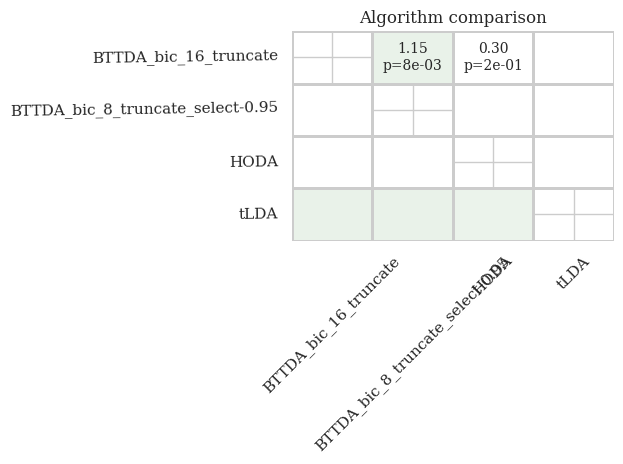

In [8]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)
plt.show()

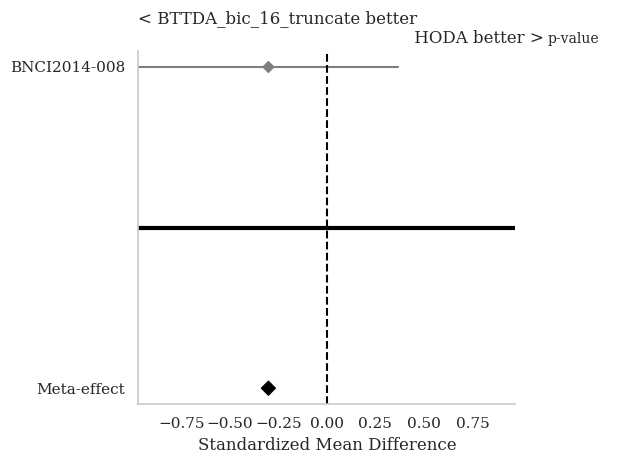

/usr/local/lib/python3.10/dist-packages/pandas/plotting/_matplotlib/core.py:1259: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(


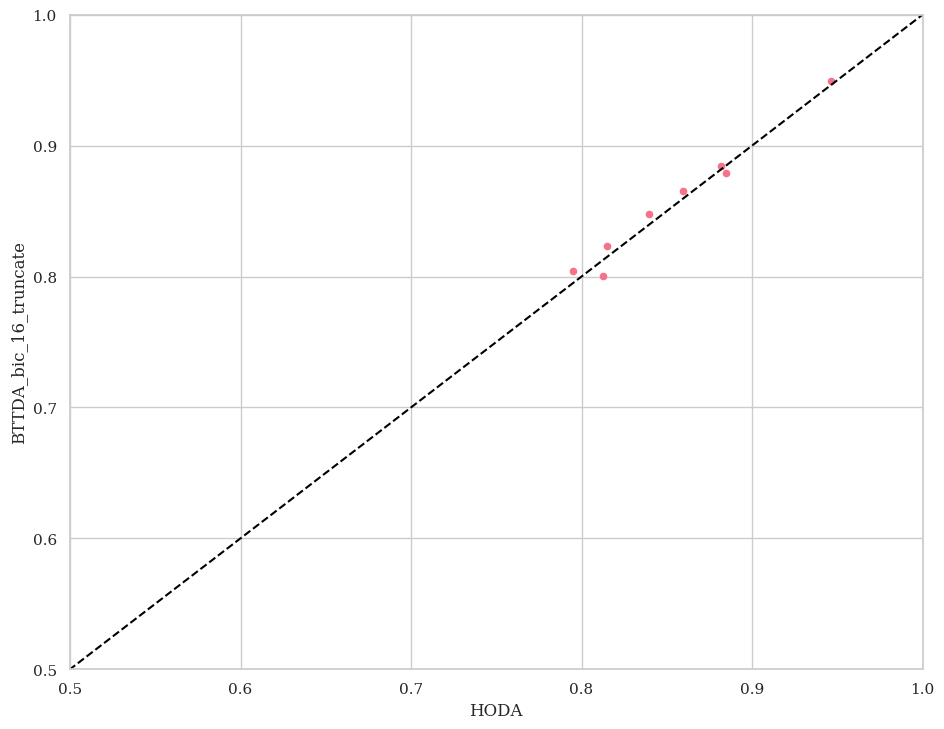

In [9]:
from moabb.analysis.plotting import meta_analysis_plot, paired_plot
_ = meta_analysis_plot(stats,  'HODA','BTTDA_bic_16_truncate')
plt.show()
_  = paired_plot(results, 'HODA', 'BTTDA_bic_16_truncate')
plt.show()
